In [53]:
%load_ext autoreload
%autoreload 2
# Select conda environment base-env with necessary libraries
# mamba activate base-env

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
# Import generic libraries
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [92]:
# Import file paths from config.py
from config import CSV_PATHS, GEOJSON_PATHS

# Section 1. Data Manipulation

## Question 1: Load the data and display a few rows of each dataset

In [58]:
# Load data
crime = pd.read_csv(CSV_PATHS['crime'])
stops = pd.read_csv(CSV_PATHS['stops'])

# Consistent lower case column namesfor easier access
crime.columns = crime.columns.str.lower()
stops.columns = stops.columns.str.lower()

In [59]:
# Display crime rows
crime.head()

,x,y,ccn,report_dat,shift,method,offense,block,xblock,yblock,...,block_group,census_tract,voting_precinct,latitude,longitude,bid,start_date,end_date,objectid,octo_record_id
0,-77.058663,38.906846,7093973,2017-06-03T12:54:27.000Z,DAY,OTHERS,THEFT FROM AUTO,2900 - 2999 BLOCK OF N STREET NW,394912,137666,...,000100 4,100.0,Precinct 5,38.906838,-77.058661,NaN,2017-06-03T11:54:03.000Z,2017-06-03T11:55:05.000Z,341397622,07093973-01
1,-77.018036,38.960747,9251904,2017-04-07T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,5800 - 5899 BLOCK OF 4TH STREET NW,398437,143648,...,001902 1,1902.0,Precinct 58,38.960739,-77.018034,NaN,2009-02-13T12:03:45.000Z,2009-02-13T12:03:43.000Z,341453326,09251904-01
2,-76.984955,38.915147,14060710,2017-03-13T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,2000 - 2099 BLOCK OF FENWICK STREET NE,401305,138586,...,008803 1,8803.0,Precinct 76,38.915139,-76.984953,NaN,2014-05-01T19:32:00.000Z,2014-05-01T19:32:00.000Z,341600002,14060710-01
3,-77.009722,38.824388,16217337,2017-04-03T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,2 - 153 BLOCK OF GALVESTON PLACE SW,399156,128511,...,009807 2,9807.0,Precinct 126,38.824380,-77.009719,NaN,2016-12-25T11:59:35.000Z,2016-12-25T20:36:17.000Z,341698884,16217337-01
4,-77.017203,38.904526,17037020,2017-03-05T20:46:01.000Z,EVENING,OTHERS,THEFT FROM AUTO,400 - 471 BLOCK OF NEW YORK AVENUE NW,398508,137407,...,004701 2,4701.0,Precinct 1,38.904518,-77.017201,MOUNT VERNON TRIANGLE CID,2017-03-05T20:14:30.000Z,NaN,341703531,17037020-01


In [60]:
# Display stops rows
stops.head()

,stop_id,officer_id,stop_date,driver_age,driver_sex,ticket
0,52595,E,3/1/2017,37,f,True
1,46141,D,3/1/2017,16,m,True
2,154271,D,3/1/2017,16,m,True
3,184170,D,3/1/2017,23,m,True
4,91155,D,3/1/2017,18,f,True


## Question 2: Crime incidents are reported to hour/minute; stops reported to the day

In [61]:
# Extract date from report date as datetime object and create new column report_daily
crime['report_daily'] = pd.to_datetime(crime['report_dat']).dt.date
print(crime['report_daily'].head())

# Also convert stop_date to datetime object
stops['report_daily'] = pd.to_datetime(stops['stop_date']).dt.date
print(stops['report_daily'].head())

0    2017-06-03
1    2017-04-07
2    2017-03-13
3    2017-04-03
4    2017-03-05
Name: report_daily, dtype: object
0    2017-03-01
1    2017-03-01
2    2017-03-01
3    2017-03-01
4    2017-03-01
Name: report_daily, dtype: object


## Question 3: Create groupby datasets: *crimes_by_day* and *stops_by_day*

In [8]:
# Count number of crimes by day
# NOTE: sort=True is groupby default, but we can be explicit to ensure the dates are in order
crimes_by_day = (crime.groupby(crime['report_daily'], 
                              as_index=False)['objectid']
                             .nunique()
                             .rename(columns={'objectid': 'count'}))

# Confirm number of unique days in report_daily matches number of rows in crimes_by_day
print(crime['report_daily'].nunique())
print(len(crimes_by_day))

# Show crimes by day
crimes_by_day.head()

182
182


,report_daily,count
0,2017-03-01,80
1,2017-03-02,59
2,2017-03-03,84
3,2017-03-04,77
4,2017-03-05,61


In [9]:
# Count number of stops by day
# NOTE: sort=True is groupby default, but we can be explicit to ensure the dates are in order
stops_by_day = (stops.groupby(stops['report_daily'], as_index=False)['stop_id']
                             .nunique()
                             .rename(columns={'stop_id': 'count'}))

# Confirm number of unique days in stop_date matches number of rows in stops_by_day
print(stops['report_daily'].nunique())
print(len(stops_by_day))

# Show stops by day
stops_by_day.head()

174
174


,report_daily,count
0,2017-03-01,509
1,2017-03-02,421
2,2017-03-03,413
3,2017-03-04,475
4,2017-03-05,490


## Question 4: Fill missing dates
Fill missing dates with actual observed values of 0 for purposes of computing statistics. If filled with Nan, statistics would be biased upward.

In [10]:
# Create simple function to fill missing dates in a DataFrame with 0 counts
def fill_missing_dates(
    df: pd.DataFrame, 
    date_col: str = "report_daily", 
    fill_col: str = "count", 
    fill_value: int = 0) -> pd.DataFrame:
    """
    Fill missing dates in a DataFrame with 0 counts.
    """
    # Create complete date range from min to max date
    date_range = pd.date_range(start=df[date_col].min(), end=df[date_col].max(), freq='D')

    # Convert date column to datetime type (if not already)
    df[date_col] = pd.to_datetime(df[date_col])
        
    # Extract dates missing from crimes_by_day 
    idx = ~date_range.isin(df[date_col])
    print(f"{sum(idx)}/{len(date_range)} missing dates.")

    # Append and sort missing dates with fill value
    if sum(idx) > 0:
        
        # Create df with missing dates and fill value
        missing_df = pd.DataFrame({date_col: date_range[idx], fill_col: fill_value})

        # Concatenate missing dates
        df = pd.concat([df, missing_df]).sort_values(by=date_col).reset_index(drop=True)
    
    return df


In [11]:
# Add missing dates to crimes_by_day
crimes_by_day = fill_missing_dates(crimes_by_day)

# Add missing dates to stops_by_day
stops_by_day = fill_missing_dates(stops_by_day)

# Show missing dates with 0 traffic stops
stops_by_day[stops_by_day["count"]==0]

0/182 missing dates.
8/182 missing dates.


,report_daily,count
29,2017-03-30,0
30,2017-03-31,0
60,2017-04-30,0
90,2017-05-30,0
91,2017-05-31,0
121,2017-06-30,0
151,2017-07-30,0
152,2017-07-31,0


# Question 5: Merge traffic stops and crime data

In [12]:
# Merge dfs
df = stops_by_day.merge(crimes_by_day, on="report_daily", how='left', suffixes=('_stops', '_crimes'))
df

,report_daily,count_stops,count_crimes
0,2017-03-01,509,80
1,2017-03-02,421,59
2,2017-03-03,413,84
3,2017-03-04,475,77
4,2017-03-05,490,61
...,...,...,...
177,2017-08-25,475,94
178,2017-08-26,471,114
179,2017-08-27,444,106
180,2017-08-28,476,74


In [13]:
# Date with max traffic stops
max_stops_date, max_stops, _ = df.loc[df['count_stops'].idxmax()]
print(f"Max traffic stops: 1) date: {max_stops_date.strftime('%Y-%m-%d')}, 2) count: {max_stops}, 3) day of week: {max_stops_date.date().strftime('%A')}")

Max traffic stops: 1) date: 2017-05-01, 2) count: 535, 3) day of week: Monday


In [14]:
# Date with max crimes
max_crimes_date, max_crimes, _ = df.loc[df['count_crimes'].idxmax()]
print(f"Max crimes: 1) date: {max_crimes_date.strftime('%Y-%m-%d')}, 2) count: {max_crimes}, 3) day of week: {max_crimes_date.date().strftime('%A')}")

Max crimes: 1) date: 2017-05-08, 2) count: 410, 3) day of week: Monday


## Question 6: most common July 4 crime

In [15]:
# Ensure report_daily is datetime type to use dt accessor
crime['report_daily'] = pd.to_datetime(crime['report_daily'])

# Extract July 4th
idx = (crime['report_daily'].dt.month == 7) & (crime['report_daily'].dt.day == 4)

# Count crimes by offense on July 4th
offense_counts = crime[idx].groupby("offense").size().sort_values(ascending=False)

# Extract most frequent offense on July 4th
print(f"Most frequent July 4 crime: {offense_counts.index[0]}, count: {offense_counts.iloc[0]}")
print(offense_counts)


Most frequent July 4 crime: THEFT FROM AUTO, count: 22
offense
THEFT FROM AUTO               22
THEFT/OTHER                   20
MOTOR VEHICLE THEFT           13
THEFT_OTHER                   11
ROBBERY                        7
ASSAULT W/DANGEROUS WEAPON     6
BURGLARY                       2
THEFT OTHER                    2
dtype: int64


# Section 2: Policy Evaluation

In [63]:
# NOTE: Courts data has 3 column names, but comma separator produces 4 columns for some rows
# Based on note that traffic tickets are in $0.50 increments, 
# I assume the extra column in some cases is using comma as a decimal separator
# NOTE: I added a dummy column name "ticket_cents" to facilitate the cleaning

# Load data
courts = pd.read_csv(CSV_PATHS['courts'])
courts.head(10)

,stop_id,ticket_amount,ticket_status,dummy
0,175978,40,overdue,NaN
1,63356,40,paid,NaN
2,92046,45,paid,NaN
3,173651,45,overdue,NaN
4,52624,65,paid,NaN
5,147991,47,overdue,NaN
6,9957,55,overdue,NaN
7,186564,40,50,paid
8,106970,45,challenged,NaN
9,65657,30,overdue,NaN


In [64]:
# Extract ticket cents from ticket_status and fill missing values in ticket_status with ticket_cents
ticket_cents = pd.to_numeric(courts['ticket_status'], errors='coerce').fillna(0)/100
courts['ticket_amount'] += ticket_cents
courts.head(10)

,stop_id,ticket_amount,ticket_status,dummy
0,175978,40.0,overdue,NaN
1,63356,40.0,paid,NaN
2,92046,45.0,paid,NaN
3,173651,45.0,overdue,NaN
4,52624,65.0,paid,NaN
5,147991,47.0,overdue,NaN
6,9957,55.0,overdue,NaN
7,186564,40.5,50,paid
8,106970,45.0,challenged,NaN
9,65657,30.0,overdue,NaN


In [65]:
# Fill missing values in ticket_status that were right shifted due to ticket_cents
idx = ~courts['dummy'].isna()
courts.loc[idx, 'ticket_status'] = courts[idx]['dummy']
# Drop dummy column
courts.drop(columns=['dummy'], inplace=True)
courts.head(10)


,stop_id,ticket_amount,ticket_status
0,175978,40.0,overdue
1,63356,40.0,paid
2,92046,45.0,paid
3,173651,45.0,overdue
4,52624,65.0,paid
5,147991,47.0,overdue
6,9957,55.0,overdue
7,186564,40.5,paid
8,106970,45.0,challenged
9,65657,30.0,overdue


In [66]:
# Read courts and income data
income = pd.read_csv(CSV_PATHS['income'])
income.head(10)

,stop_id,income
0,97294,26305
1,87077,77578
2,57432,80185
3,121675,98784
4,37238,9350
5,199246,31981
6,191139,42301
7,153865,52278
8,90007,21719
9,111167,34801


In [67]:
# Merge courts and income data on stop_id
df = courts.merge(income, on="stop_id", how='left')

# Check lengths of courts, income, and merged df to confirm merge worked as expected
print(len(courts), len(income), len(df))
df.head()

60257 60268 60257


,stop_id,ticket_amount,ticket_status,income
0,175978,40.0,overdue,NaN
1,63356,40.0,paid,104461.0
2,92046,45.0,paid,67931.0
3,173651,45.0,overdue,35424.0
4,52624,65.0,paid,88920.0


## Question 7: delta probability less/greater than $30,000

In [47]:
INCOME_THRESHOLD = 30000
# Extract low income people
low_income = (df['income'] < INCOME_THRESHOLD)
# Extract low income people with paid tickes
paid_low_income = (df['ticket_status'] == 'paid') & low_income
# Compute probability of paid ticket for low income people
prob_paid_low_income = sum(paid_low_income) / sum(low_income)
print(f"Probability of paid ticket for low income: {prob_paid_low_income:.2%}")

# Extract high income people
high_income = (df['income'] >= INCOME_THRESHOLD)
# Extract high income people with paid tickes
paid_high_income = (df['ticket_status'] == 'paid') & high_income
# Compute probability of paid ticket for high income people
prob_paid_high_income = sum(paid_high_income) / sum(high_income)
print(f"Probability of paid ticket for high income: {prob_paid_high_income:.2%}")


Probability of paid ticket for low income: 35.52%
Probability of paid ticket for high income: 30.16%


In [52]:
from scipy import stats


ModuleNotFoundError: No module named 'scipy'

In [48]:
delta_prob = prob_paid_low_income - prob_paid_high_income
delta_prob

0.053536870855838636

## Question 8: Magintude of impact
Low income individuals have a 5% point greater probability of paying their traffic tickes than high income individuals. 

## Question 9: Results across income thresholds

In [51]:
INCOME_THRESHOLDS = np.arange(5000, 55000, 5000)
INCOME_THRESHOLDS

array([ 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000,
       50000])

## Question 10: Discussion of impact

# Section 3: Data Visualization
## Question 11: 

In [134]:
DC_UTM_EPSG = 32618

In [91]:
# Read address points data
# Columns of interest: "RESIDENTIAL_TYPE"
address_points = gpd.read_file(GEOJSON_PATHS['address_points'])
print(address_points.columns)
address_points["RESIDENTIAL_TYPE"].value_counts()

Index(['OBJECTID', 'MAR_ID', 'ADDRESS', 'ADDRESS_NUMBER',
       'ADDRESS_NUMBER_SUFFIX', 'STREET_NAME', 'STREET_TYPE', 'QUADRANT',
       'ZIPCODE', 'CITY', 'STATE', 'COUNTRY', 'X_COORDINATE', 'Y_COORDINATE',
       'LATITUDE', 'LONGITUDE', 'ADDRESS_TYPE', 'STATUS', 'ROUTEID',
       'BLOCKKEY', 'SUBBLOCKKEY', 'WARD', 'METADATA_ID', 'NATIONAL_GRID',
       'HAS_SSL', 'HAS_PLACE_NAME', 'HAS_CONDO', 'HAS_RESIDENTIAL_UNIT',
       'STREET_VIEW_URL', 'RESIDENTIAL_TYPE', 'PLACEMENT', 'SSL_ALIGNMENT',
       'BUILDING', 'SSL', 'SQUARE', 'SUFFIX', 'LOT', 'MULTIPLE_LAND_SSL',
       'GRID_DIRECTION', 'HOUSING_UNIT_COUNT', 'RESIDENTIAL_UNIT_COUNT',
       'BEFORE_DATE', 'BEFORE_DATE_SOURCE', 'BEGIN_DATE', 'BEGIN_DATE_SOURCE',
       'FIRST_KNOWN_DATE', 'FIRST_KNOWN_DATE_SOURCE', 'CREATED_DATE',
       'LAST_EDITED_DATE', 'SE_ANNO_CAD_DATA', 'SMD', 'ANC', 'geometry'],
      dtype='str')


RESIDENTIAL_TYPE
RESIDENTIAL        130417
NON RESIDENTIAL     13307
MIXED USE             648
Name: count, dtype: int64

Index(['NAME', 'STATION_TYPE', 'STATION_ID', 'STATION_STATUS', 'LAST_REPORTED',
       'NUM_DOCKS_AVAILABLE', 'NUM_DOCKS_DISABLED', 'NUM_BIKES_AVAILABLE',
       'NUM_EBIKES_AVAILABLE', 'NUM_BIKES_DISABLED', 'IS_INSTALLED',
       'IS_RETURNING', 'IS_RENTING', 'HAS_KIOSK', 'IOS', 'ANDROID',
       'ELECTRIC_BIKE_SURCHARGE_WAIVER', 'EIGHTD_HAS_KEY_DISPENSER',
       'CAPACITY', 'RENTAL_METHODS', 'REGION_ID', 'REGION_NAME', 'GIS_ID',
       'LATITUDE', 'LONGITUDE', 'GIS_LAST_MOD_DTTM', 'OBJECTID', 'geometry'],
      dtype='str')


<Axes: >

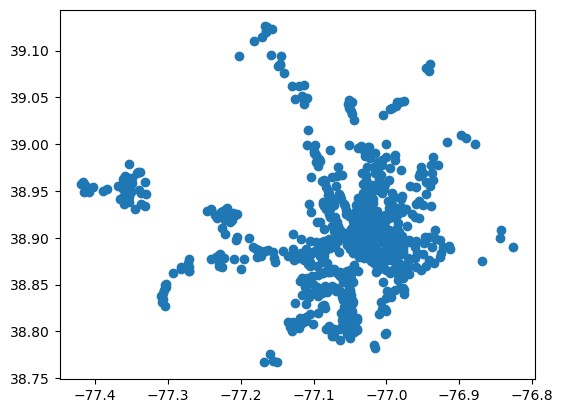

In [90]:
# Read bike share locations data
# Columns of interest: "NUM_DOCKS_AVAILABLE", "NUM_BIKES_AVAILABLE", "IS_RENTING", "IS_RETURNING"
bike_share_locations = gpd.read_file(GEOJSON_PATHS['bike_share_locations'])
print(bike_share_locations.columns)
bike_share_locations.plot()

Index(['ROUTEID', 'ROUTENAME', 'ROADTYPE', 'SUBBLOCKKEY',
       'BIKELANE_PARKINGLANE_ADJACENT', 'BIKELANE_THROUGHLANE_ADJACENT',
       'BIKELANE_POCKETLANE_ADJACENT', 'BIKELANE_CONTRAFLOW',
       'BIKELANE_CONVENTIONAL', 'BIKELANE_DUAL_PROTECTED',
       'BIKELANE_DUAL_BUFFERED', 'BIKELANE_PROTECTED', 'BIKELANE_BUFFERED',
       'SUBBLOCKID', 'BLOCKID', 'BLOCKKEY', 'QUADRANT', 'STREETNAME',
       'STREETTYPE', 'TOTALBIKELANES', 'TOTALBIKELANEWIDTH', 'WARD_ID',
       'SMD_ID', 'ANC_ID', 'OBJECTID', 'SHAPELEN', 'geometry'],
      dtype='str')


<Axes: >

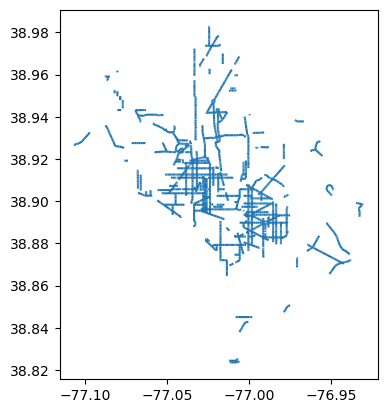

In [89]:
# Read bike lanes data
# COLUMNS OF INTEREST: "ROADTYPE", "TOTALBIKELANEWIDTH", "BIKELANE_PROTECTED", "BIKELANE_BUFFERED"
bike_lanes = gpd.read_file(GEOJSON_PATHS['bike_lanes'])
print(bike_lanes.columns)
bike_lanes.plot()

In [88]:
# Read mass appraisal data
appraisal = pd.read_csv(CSV_PATHS['appraisal'])
# Columns of interest: "AVLAND", "AVTOTAL", "BLDGCL", "USECODE"
print(appraisal.columns)
appraisal.head()

Index(['OBJECTID', 'SSL', 'BATHRM', 'HF_BATHRM', 'HEAT', 'HEAT_D', 'AC',
       'NUM_UNITS', 'ROOMS', 'BEDRM', 'AYB', 'YR_RMDL', 'EYB', 'STORIES',
       'SALEDATE', 'PRICE', 'QUALIFIED', 'SALE_NUM', 'GBA', 'BLDG_NUM',
       'STYLE', 'STYLE_D', 'STRUCT', 'STRUCT_D', 'GRADE', 'GRADE_D', 'CNDTN',
       'CNDTN_D', 'EXTWALL', 'EXTWALL_D', 'ROOF', 'ROOF_D', 'INTWALL',
       'INTWALL_D', 'KITCHENS', 'FIREPLACES', 'USECODE', 'LANDAREA',
       'GIS_LAST_MOD_DTTM'],
      dtype='str')


,OBJECTID,SSL,BATHRM,HF_BATHRM,HEAT,HEAT_D,AC,NUM_UNITS,ROOMS,BEDRM,...,EXTWALL_D,ROOF,ROOF_D,INTWALL,INTWALL_D,KITCHENS,FIREPLACES,USECODE,LANDAREA,GIS_LAST_MOD_DTTM
0,184582008,0132 0216,5.0,1.0,1.0,Forced Air,Y,3.0,15.0,6.0,...,Stone/Stucco,2.0,Built Up,6.0,Hardwood,3.0,6.0,25,1381,2026/04/08 05:16:11+00
1,184582009,0132 0217,5.0,0.0,1.0,Forced Air,Y,5.0,13.0,5.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,5.0,0.0,25,1381,2026/04/08 05:16:11+00
2,184582010,0132 0222,2.0,0.0,1.0,Forced Air,Y,1.0,8.0,5.0,...,Common Brick,6.0,Metal- Sms,6.0,Hardwood,1.0,1.0,11,1620,2026/04/08 05:16:11+00
3,184582011,0132 0223,4.0,1.0,8.0,Ht Pump,Y,1.0,12.0,4.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,1.0,0.0,11,1575,2026/04/08 05:16:11+00
4,184582012,0132 0227,2.0,0.0,7.0,Warm Cool,Y,2.0,6.0,2.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,2.0,2.0,24,2250,2026/04/08 05:16:11+00


In [175]:
# 
housing_cols = {
    "DP04_0038E": "total_units",
    "DP04_0020E": "occupied_units"
}


In [176]:
# Read housing characteristics data
housing = gpd.read_file(GEOJSON_PATHS['housing_characteristics'])
print(housing.columns)

# Rename columns of interest
housing = housing.rename(columns=housing_cols)


Index(['NAME', 'DP04_0038E', 'DP04_0040E', 'DP04_0041E', 'DP04_0042E',
       'DP04_0043E', 'DP04_0044E', 'DP04_0039E', 'GEOID', 'GIS_ID',
       ...
       'DP04_0023E', 'DP04_0022E', 'DP04_0021E', 'DP04_0020E', 'DP04_0019E',
       'DP04_0018E', 'DP04_0017E', 'TRACTCE', 'OBJECTID', 'geometry'],
      dtype='str', length=152)


In [177]:
# Extract numeric columns
nonnumeric_cols = ["GIS_ID","geometry"]
numeric_cols = [col for col in housing.columns if col not in nonnumeric_cols]

# Convert numeric columns to numeric type, coercing errors to NaN
# Remove thousands separator commas, which cause conversion to numeric to fail
housing = housing.replace(',', '', regex=True)
housing[numeric_cols] = housing[numeric_cols].apply(pd.to_numeric, errors='coerce')
housing.head(10)

,NAME,total_units,DP04_0040E,DP04_0041E,DP04_0042E,DP04_0043E,DP04_0044E,DP04_0039E,GEOID,GIS_ID,...,DP04_0023E,DP04_0022E,DP04_0021E,occupied_units,DP04_0019E,DP04_0018E,DP04_0017E,TRACTCE,OBJECTID,geometry
0,1.01,898,442,166,45,45,50,150,11001000101,ACS_Housing_DC_CensusTract_11,...,57,26,19,8,15,19,0,101,11,"POLYGON ((-77.05121 38.91078, -77.05126 38.910..."
1,1.02,2207,464,625,507,284,158,169,11001000102,ACS_Housing_DC_CensusTract_8,...,197,30,40,30,12,0,0,102,8,"POLYGON ((-77.0669 38.91866, -77.06726 38.9186..."
2,2.01,0,0,0,0,0,0,0,11001000201,ACS_Housing_DC_CensusTract_100,...,0,0,0,0,0,0,0,201,100,"POLYGON ((-77.07412 38.91259, -77.07433 38.912..."
3,2.02,1977,294,512,748,195,184,44,11001000202,ACS_Housing_DC_CensusTract_141,...,68,51,424,10,22,54,0,202,141,"POLYGON ((-77.06568 38.91183, -77.06583 38.912..."
4,3.00,2793,718,363,730,607,312,63,11001000300,ACS_Housing_DC_CensusTract_101,...,67,62,338,84,50,101,0,300,101,"POLYGON ((-77.0743 38.92256, -77.0747 38.92256..."
5,4.00,885,156,187,94,92,281,75,11001000400,ACS_Housing_DC_CensusTract_102,...,19,66,99,68,59,210,15,400,102,"POLYGON ((-77.06639 38.92753, -77.06639 38.928..."
6,5.01,2559,1028,667,180,33,104,547,11001000501,ACS_Housing_DC_CensusTract_126,...,555,151,299,107,75,183,0,501,126,"POLYGON ((-77.04452 38.92835, -77.04454 38.928..."
7,5.02,1815,671,454,191,221,185,93,11001000502,ACS_Housing_DC_CensusTract_103,...,80,55,10,6,0,58,0,502,103,"POLYGON ((-77.05699 38.93258, -77.05707 38.932..."
8,6.00,2287,653,262,243,244,620,265,11001000600,ACS_Housing_DC_CensusTract_110,...,111,21,57,0,16,44,0,600,110,"POLYGON ((-77.07508 38.94223, -77.07601 38.942..."
9,7.02,2503,1223,569,100,12,13,586,11001000702,ACS_Housing_DC_CensusTract_111,...,568,243,56,26,9,0,0,702,111,"POLYGON ((-77.08051 38.92601, -77.0813 38.9260..."


AttributeError: 'GeoDataFrame' object has no attribute 'series'

In [157]:
# Compute area in hectares
housing['area_ha'] = housing.to_crs(DC_UTM_EPSG).area / 10000

/Users/carlossilva/miniforge3/envs/base-env/lib/python3.14/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [158]:
housing["unit_density"] = housing["total_units"] / housing["area_ha"]

<Axes: >

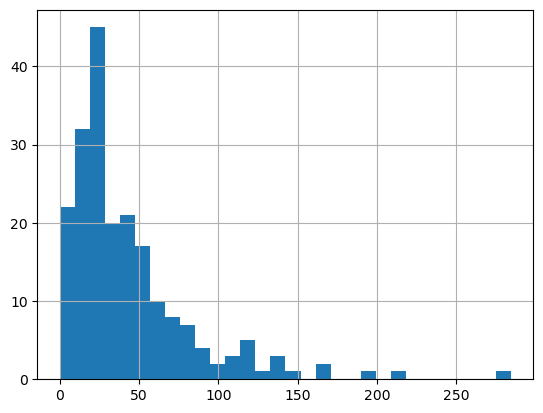

In [147]:
housing["unit_density"].hist(bins=30)

In [152]:
housing['unit_density'].max()

np.float64(284.53297432824166)

<Axes: >

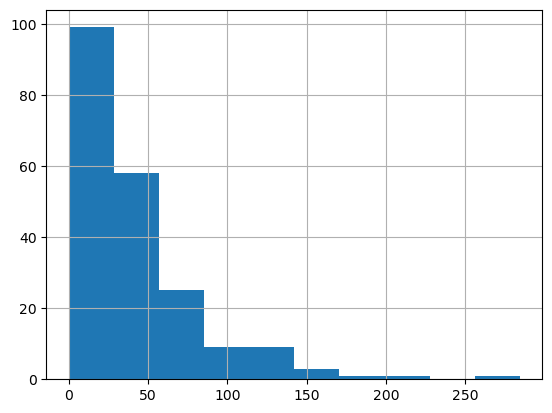

In [162]:
housing['unit_density'].hist()

<Axes: >

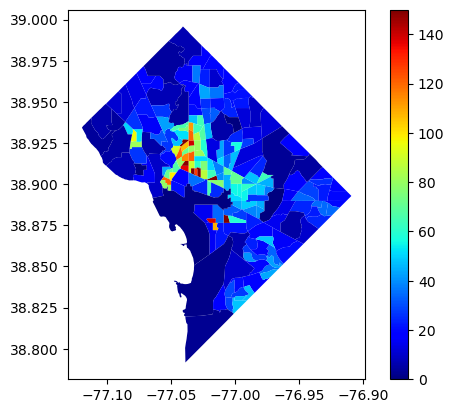

In [167]:
housing.plot(column='unit_density', 
             #norm=LogNorm(vmin=.01, vmax=285), 
             vmin=0, vmax=150,
             cmap='jet',
             legend=True)


# Remnants

In [ ]:
# Create complete date list to identify missing dates
crimes_date_range = pd.date_range(start=crimes_by_day['report_daily'].min(), 
                           end=crimes_by_day['report_daily'].max(), freq='D')

# Ensure crimes_by_day['report_daily'] is datetime object for comparison
crimes_by_day['report_daily'] = pd.to_datetime(crimes_by_day['report_daily'])

# Extract dates missing from crimes_by_day 
idx = ~crimes_date_range.isin(crimes_by_day['report_daily'])

# No missing dates in crimes_by_day
print(f"{sum(idx)} missing dates in crimes_by_day")

0 missing dates in crimes_by_day


In [ ]:
# Create complete date list to identify missing dates
stops_date_range = pd.date_range(start=stops_by_day['stop_date'].min(), 
                           end=stops_by_day['stop_date'].max(), freq='D')

# Ensure stops_by_day['stop_date'] is datetime object for comparison
stops_by_day['stop_date'] = pd.to_datetime(stops_by_day['stop_date'])

# Extract dates missing from stops_by_day
idx = ~stops_date_range.isin(stops_by_day['stop_date'])

# NOTE: 8 dates missing from stops_by_day
print(f"{sum(idx)} missing dates in stops_by_day")

8 missing dates in stops_by_day


In [ ]:
stops_by_day = (stops_by_day.set_index('stop_date')
                .resample('D')
                .asfreq()
                .fillna(0)).reset_index(drop=True)

print(f"len(crimes_by_day): {len(crimes_by_day)}")
print(f"len(stops_by_day): {len(stops_by_day)}")